# T5YIE Sentiment/Text Exogenous EDA (Phase 3)

Focused forecasting-oriented EDA of engineered text features versus 	5yie_diff1.

Primary alignment:
- monthly lagged features (M-1) to target month (M)

Secondary diagnostics:
- daily event-window checks with explicit shift to avoid same-day leakage.


## 1) Data Sources + Schema Audit


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sqlite3

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid')
pd.options.display.max_columns = 200


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / '.git').exists():
            return candidate
    raise FileNotFoundError('Repo root not found')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
TARGET_PATH = REPO_ROOT / 'data' / 'targets' / 't5yie_diff1.parquet'
FEATURES_PATH = REPO_ROOT / 'data' / 'features' / 'doc_level' / 'features.parquet'
TARGET_MANIFEST_DIR = REPO_ROOT / 'data' / 'targets' / 'manifests'
FEATURES_REGISTRY_PATH = REPO_ROOT / 'data' / 'features' / 'doc_level' / 'dataset_registry.sqlite3'

REQ_TARGET = {'date', 't5yie_diff1'}
REQ_FEATURES = {
    'doc_id', 'source_type', 'date', 'hawkish_score', 'n_hawkish', 'n_dovish',
    'n_neutral', 'n_target_sentences', 'novelty'
}
MONTHLY_FEATURE_COLS = [
    'hawkish_score', 'novelty', 'n_hawkish', 'n_dovish',
    'n_neutral', 'n_target_sentences', 'doc_count'
]

assert TARGET_PATH.exists(), f'Missing {TARGET_PATH}'
assert FEATURES_PATH.exists(), f'Missing {FEATURES_PATH}'

print('repo_root:', REPO_ROOT)
print('target_path:', TARGET_PATH)
print('features_path:', FEATURES_PATH)


repo_root: C:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting
target_path: C:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\targets\t5yie_diff1.parquet
features_path: C:\Users\eladb\OneDrive\Desktop\repos\fomc-forecasting\fomc-forecasting\data\features\doc_level\features.parquet


In [2]:
def norm_dates(df: pd.DataFrame, col: str = 'date') -> pd.DataFrame:
    out = df.copy()
    out[col] = pd.to_datetime(out[col], errors='coerce').dt.normalize()
    out = out.dropna(subset=[col]).sort_values(col).reset_index(drop=True)
    return out


target_df = norm_dates(pd.read_parquet(TARGET_PATH), 'date')
features_df = norm_dates(pd.read_parquet(FEATURES_PATH), 'date')

assert not (REQ_TARGET - set(target_df.columns)), 'Target schema mismatch'
assert not (REQ_FEATURES - set(features_df.columns)), 'Feature schema mismatch'

# Assertion 1
assert target_df['date'].is_monotonic_increasing
assert target_df['date'].is_unique

print('target rows:', len(target_df), 'range:', target_df['date'].min().date(), '->', target_df['date'].max().date())
print('features rows:', len(features_df), 'range:', features_df['date'].min().date(), '->', features_df['date'].max().date())
print('source_type counts:')
print(features_df['source_type'].value_counts(dropna=False))

display(target_df.head(3))
display(features_df.head(3))

manifest_files = sorted(TARGET_MANIFEST_DIR.glob('targets-t5yie-*.json'))
if manifest_files:
    latest_manifest = max(manifest_files, key=lambda p: p.stat().st_mtime)
    print('latest_t5yie_manifest:', latest_manifest.name)
    display(pd.Series(json.loads(latest_manifest.read_text(encoding='utf-8'))).to_frame('value'))

if FEATURES_REGISTRY_PATH.exists():
    with sqlite3.connect(FEATURES_REGISTRY_PATH) as conn:
        tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn)
        display(tables)
        if 'dataset_registry' in tables['name'].tolist():
            display(pd.read_sql_query('SELECT * FROM dataset_registry ORDER BY rowid DESC LIMIT 1', conn))


target rows: 5808 range: 2003-01-03 -> 2026-03-24
features rows: 1695 range: 1994-02-04 -> 2026-03-03
source_type counts:
source_type
speech      1308
document     387
Name: count, dtype: int64


,date,t5yie_diff1
0,2003-01-03,-0.02
1,2003-01-06,0.03
2,2003-01-07,-0.03


,doc_id,source_type,date,hawkish_score,n_hawkish,n_dovish,n_neutral,n_target_sentences,novelty
0,512,document,1994-02-04,1.0,1,0,0,1,1.000000
1,514,document,1994-03-22,0.0,0,0,0,0,0.131005
2,516,document,1994-04-18,1.0,1,0,0,1,0.110982


latest_t5yie_manifest: targets-t5yie-20260325T201339Z.json


,value
created_at_utc,2026-03-25T20:13:39+00:00
dataset_version,targets-t5yie-20260325T201339Z
extra,{'fred_api_key_env': 'FRED_API_KEY'}
fetch_end,None
fetch_start,None
git_sha,a3d3f6651abefa2308c2c0b92a143e2ce0cee2aa
raw_output_path,C:\Users\eladb\OneDrive\Desktop\repos\fomc-for...
raw_output_rows,5809
raw_output_sha256,c9a46249e10c48fc95dff86bdc0679ccaad172d3d0acd2...
series_id,T5YIE


,name
0,dataset_registry


,dataset_version,created_at_utc,git_sha,output_path,output_sha256,output_rows,source_types,input_db_path,input_db_sha256,cleaning_version,sentence_split_version,metadata_json
0,features-20260323T234522Z,2026-03-23T23:45:22+00:00,4f7c5ec75a71fc2eabceceaf58778977120d5d5d,C:\Users\eladb\AppData\Local\Temp\pytest-of-el...,None,2,"[""speeches"", ""documents""]",C:\Users\eladb\OneDrive\Desktop\repos\fomc-for...,de3802ac9888c340ae1c6e14ae7e3bc3347a9a03ebfd50...,1.0.0,1.0.0,"{""max_retries"": null}"


## 2) Integrity and Frequency Alignment


target date deltas


,target_delta
count,5807
mean,1 days 11:03:05.362493542
std,0 days 21:22:07.321543323
min,1 days 00:00:00
25%,1 days 00:00:00
50%,1 days 00:00:00
75%,1 days 00:00:00
max,4 days 00:00:00


,count
1 days,4529
3 days,1028
4 days,184
2 days,66


feature date deltas


,feature_delta
count,1334
mean,8 days 18:45:52.623688155
std,20 days 22:43:53.230658300
min,1 days 00:00:00
25%,2 days 00:00:00
50%,5 days 00:00:00
75%,9 days 00:00:00
max,553 days 00:00:00


,count
1 days,297
2 days,155
5 days,115
4 days,105
3 days,100
6 days,78
7 days,74
8 days,57
12 days,36
9 days,35


target months: 279 feature months: 316 overlap: 265
overlap range: 2003-01 -> 2026-03


,target_obs_per_month
count,279.000000
mean,20.817204
std,1.186976
min,17.000000
25%,20.000000
50%,21.000000
75%,22.000000
max,23.000000


,feature_docs_per_month
count,316.000000
mean,5.363924
std,3.780967
min,1.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,20.000000


source_type,document,speech
month,,
2025-04,0,13
2025-05,2,15
2025-06,2,11
2025-07,2,8
2025-08,0,7
2025-09,2,7
2025-10,2,18
2025-11,0,11
2025-12,2,2


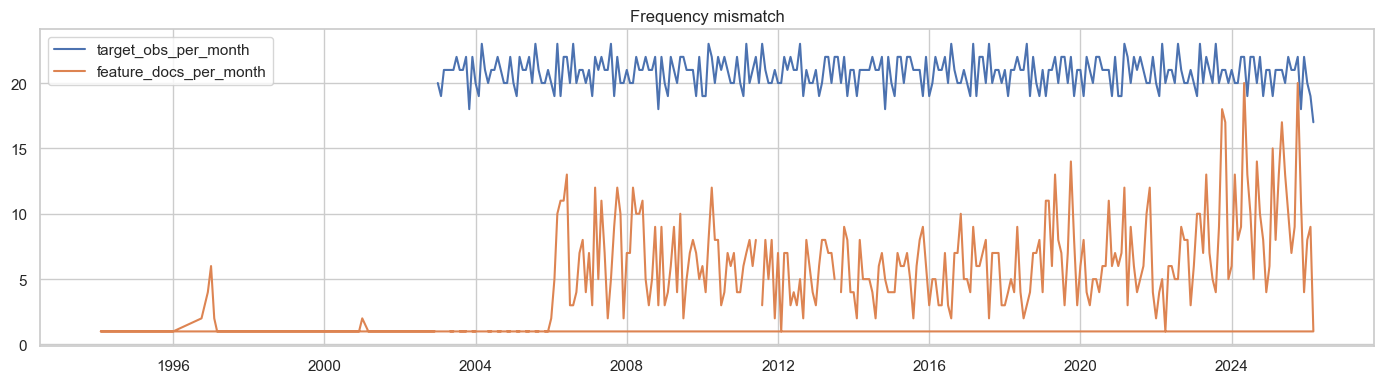

In [3]:
def delta_summary(s: pd.Series) -> tuple[pd.Series, pd.Series]:
    d = pd.Series(pd.to_datetime(s, errors='coerce').dropna().sort_values().unique())
    deltas = d.diff().dropna()
    return deltas.describe(), deltas.value_counts().head(10)


t_desc, t_top = delta_summary(target_df['date'])
f_desc, f_top = delta_summary(features_df['date'])
print('target date deltas')
display(t_desc.to_frame('target_delta'))
display(t_top.to_frame('count'))
print('feature date deltas')
display(f_desc.to_frame('feature_delta'))
display(f_top.to_frame('count'))

target_m = target_df.assign(month=target_df['date'].dt.to_period('M')).groupby('month').size().rename('target_obs')
feature_m = features_df.assign(month=features_df['date'].dt.to_period('M')).groupby('month').size().rename('feature_docs')
feature_m_type = features_df.assign(month=features_df['date'].dt.to_period('M')).groupby(['month','source_type']).size().unstack(fill_value=0)

ov = sorted(set(target_m.index) & set(feature_m.index))
print('target months:', len(target_m), 'feature months:', len(feature_m), 'overlap:', len(ov))
if ov:
    print('overlap range:', ov[0], '->', ov[-1])

display(target_m.describe().to_frame('target_obs_per_month'))
display(feature_m.describe().to_frame('feature_docs_per_month'))
display(feature_m_type.tail(12))

p = pd.concat([target_m, feature_m], axis=1).reset_index()
p['month_start'] = p['month'].dt.to_timestamp()
plt.figure(figsize=(14,4))
plt.plot(p['month_start'], p['target_obs'], label='target_obs_per_month')
plt.plot(p['month_start'], p['feature_docs'], label='feature_docs_per_month')
plt.legend(); plt.title('Frequency mismatch'); plt.tight_layout(); plt.show()


## 3) Primary Merge (Monthly, No Lookahead)

Alignment:
- aggregate features monthly
- aggregate target monthly mean
- align target month M with feature month M-1


In [4]:
target_monthly = (
    target_df.assign(target_month=target_df['date'].dt.to_period('M'))
    .groupby('target_month')
    .agg(
        t5yie_diff1=('t5yie_diff1', 'mean'),
        t5yie_diff1_abs_mean=('t5yie_diff1', lambda s: s.abs().mean()),
        t5yie_obs=('t5yie_diff1', 'size'),
    )
    .reset_index()
    .sort_values('target_month')
    .reset_index(drop=True)
)

features_monthly = (
    features_df.assign(feature_month=features_df['date'].dt.to_period('M'))
    .groupby('feature_month')
    .agg(
        hawkish_score=('hawkish_score', 'mean'),
        novelty=('novelty', 'mean'),
        n_hawkish=('n_hawkish', 'sum'),
        n_dovish=('n_dovish', 'sum'),
        n_neutral=('n_neutral', 'sum'),
        n_target_sentences=('n_target_sentences', 'sum'),
        doc_count=('doc_id', 'count'),
    )
    .reset_index()
    .sort_values('feature_month')
    .reset_index(drop=True)
)

features_monthly_by_type = (
    features_df.assign(feature_month=features_df['date'].dt.to_period('M'))
    .groupby(['feature_month', 'source_type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

monthly_eda = target_monthly[['target_month', 't5yie_diff1', 't5yie_diff1_abs_mean', 't5yie_obs']].copy()
monthly_eda['feature_month_used'] = monthly_eda['target_month'] - 1
monthly_eda = monthly_eda.merge(
    features_monthly,
    left_on='feature_month_used',
    right_on='feature_month',
    how='left',
).drop(columns=['feature_month']).sort_values('target_month').reset_index(drop=True)

# Assertion 2
assert (monthly_eda['feature_month_used'] < monthly_eda['target_month']).all(), 'No-lookahead check failed'

# Assertion 4
assert len(monthly_eda) == len(target_monthly), 'Monthly merge row mismatch'

print('monthly target rows:', len(target_monthly))
print('monthly feature rows:', len(features_monthly))
print('monthly aligned rows:', len(monthly_eda))
display(monthly_eda.head(8))
display(features_monthly_by_type.tail(12))


monthly target rows: 279
monthly feature rows: 316
monthly aligned rows: 279


,target_month,t5yie_diff1,t5yie_diff1_abs_mean,t5yie_obs,feature_month_used,hawkish_score,novelty,n_hawkish,n_dovish,n_neutral,n_target_sentences,doc_count
0,2003-01,0.009500,0.035500,20,2002-12,0.0,0.113067,0.0,0.0,1.0,1.0,1.0
1,2003-02,0.013684,0.033684,19,2003-01,0.0,0.204370,0.0,0.0,1.0,1.0,1.0
2,2003-03,-0.004762,0.052381,21,2003-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2003-04,-0.009524,0.028571,21,2003-03,0.0,0.144288,0.0,0.0,1.0,1.0,1.0
4,2003-05,-0.009048,0.050000,21,2003-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2003-06,0.009048,0.026190,21,2003-05,-1.0,0.167235,0.0,1.0,0.0,1.0,1.0
6,2003-07,0.013636,0.032727,22,2003-06,-1.0,0.151147,0.0,2.0,0.0,2.0,1.0
7,2003-08,0.011429,0.034286,21,2003-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN


source_type,feature_month,document,speech
304,2025-04,0,13
305,2025-05,2,15
306,2025-06,2,11
307,2025-07,2,8
308,2025-08,0,7
309,2025-09,2,7
310,2025-10,2,18
311,2025-11,0,11
312,2025-12,2,2
313,2026-01,1,7


## 4) Missingness Semantics

Missing reasons:
- pre_feature_history
- no_docs_month
- residual_true_gap


first feature month: 1994-02


,feature,missing_n,missing_rate,pre_feature_history,no_docs_month,residual_true_gap
0,hawkish_score,14,0.050179,0,14,0
1,novelty,14,0.050179,0,14,0
2,n_hawkish,14,0.050179,0,14,0
3,n_dovish,14,0.050179,0,14,0
4,n_neutral,14,0.050179,0,14,0
5,n_target_sentences,14,0.050179,0,14,0
6,doc_count,14,0.050179,0,14,0


,count
reason,
no_docs_month,14


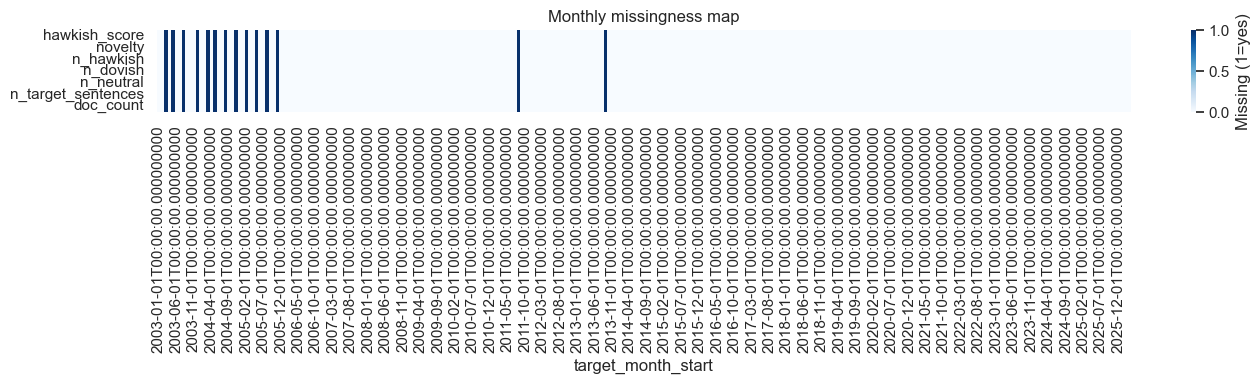

In [5]:
months_with_docs = set(features_monthly.loc[features_monthly['doc_count'] > 0, 'feature_month'])
assert len(months_with_docs) > 0, 'No months with docs found'
first_feature_month = min(months_with_docs)

monthly_eda['missing_period_reason'] = np.select(
    [
        monthly_eda['feature_month_used'] < first_feature_month,
        ~monthly_eda['feature_month_used'].isin(months_with_docs),
    ],
    ['pre_feature_history', 'no_docs_month'],
    default='residual_true_gap',
)

missing_rows = []
for col in MONTHLY_FEATURE_COLS:
    miss = monthly_eda[col].isna()
    counts = monthly_eda.loc[miss, 'missing_period_reason'].value_counts()

    # Assertion 5
    assert int(counts.sum()) == int(miss.sum()), f'Missing decomposition mismatch for {col}'

    missing_rows.append(
        {
            'feature': col,
            'missing_n': int(miss.sum()),
            'missing_rate': float(miss.mean()),
            'pre_feature_history': int(counts.get('pre_feature_history', 0)),
            'no_docs_month': int(counts.get('no_docs_month', 0)),
            'residual_true_gap': int(counts.get('residual_true_gap', 0)),
        }
    )

missing_semantics = pd.DataFrame(missing_rows).sort_values('missing_rate', ascending=False)
any_miss = monthly_eda[MONTHLY_FEATURE_COLS].isna().any(axis=1)
overall_reasons = monthly_eda.loc[any_miss, 'missing_period_reason'].value_counts().rename_axis('reason').to_frame('count')
assert int(overall_reasons['count'].sum()) == int(any_miss.sum()), 'Overall missing decomposition mismatch'

print('first feature month:', first_feature_month)
display(missing_semantics)
display(overall_reasons)

mh = monthly_eda[['target_month'] + MONTHLY_FEATURE_COLS].copy()
mh['target_month_start'] = mh['target_month'].dt.to_timestamp()
heat = mh.set_index('target_month_start')[MONTHLY_FEATURE_COLS].isna().astype(int)
plt.figure(figsize=(14,4))
sns.heatmap(heat.T, cmap='Blues', cbar_kws={'label': 'Missing (1=yes)'})
plt.title('Monthly missingness map')
plt.tight_layout(); plt.show()


## 5) Descriptive EDA


,count,mean,std,min,25%,50%,75%,max,missing_rate
t5yie_diff1,279.0,0.000268,0.012537,-0.087727,-0.005251,0.000476,0.006511,0.090000,0.000000
hawkish_score,265.0,0.066111,0.240073,-1.000000,-0.069467,0.071469,0.211111,0.636364,0.050179
novelty,265.0,0.567832,0.250648,0.077930,0.418278,0.636341,0.759413,0.941229,0.050179
n_hawkish,265.0,29.396226,29.356443,0.000000,9.000000,19.000000,39.000000,158.000000,0.050179
n_dovish,265.0,20.015094,15.334149,0.000000,8.000000,18.000000,29.000000,63.000000,0.050179
n_neutral,265.0,44.143396,37.767859,0.000000,19.000000,38.000000,61.000000,241.000000,0.050179
n_target_sentences,265.0,93.554717,70.580425,0.000000,46.000000,86.000000,127.000000,357.000000,0.050179
doc_count,265.0,6.154717,3.609046,1.000000,4.000000,6.000000,8.000000,20.000000,0.050179


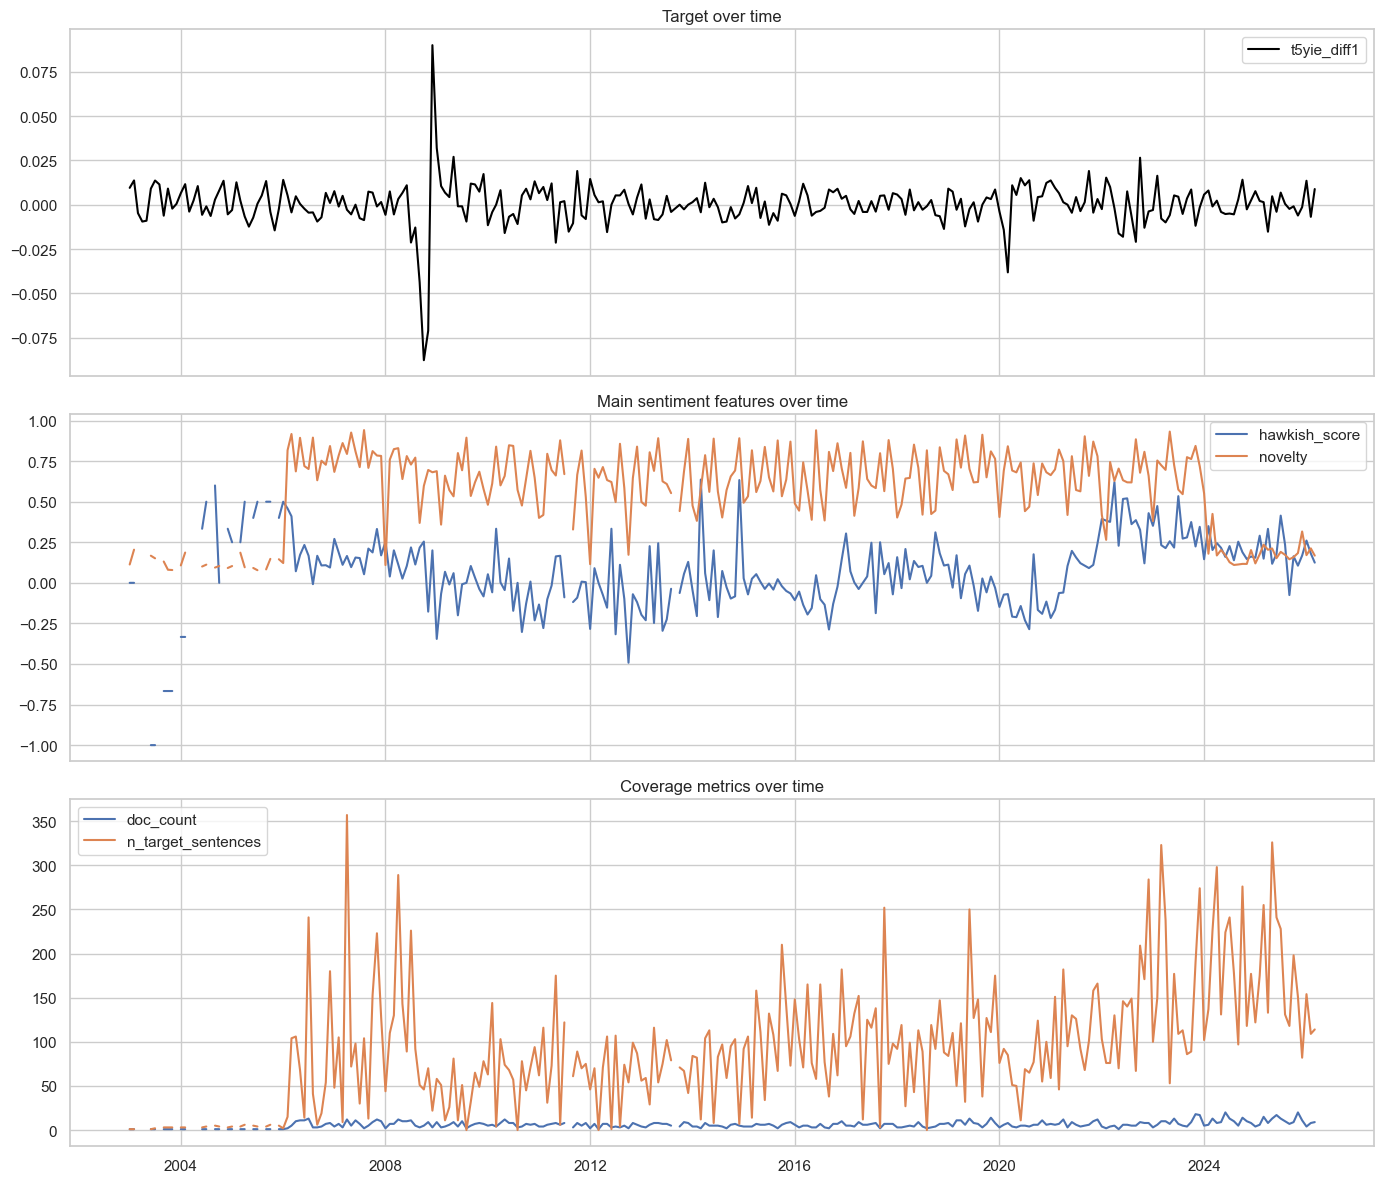

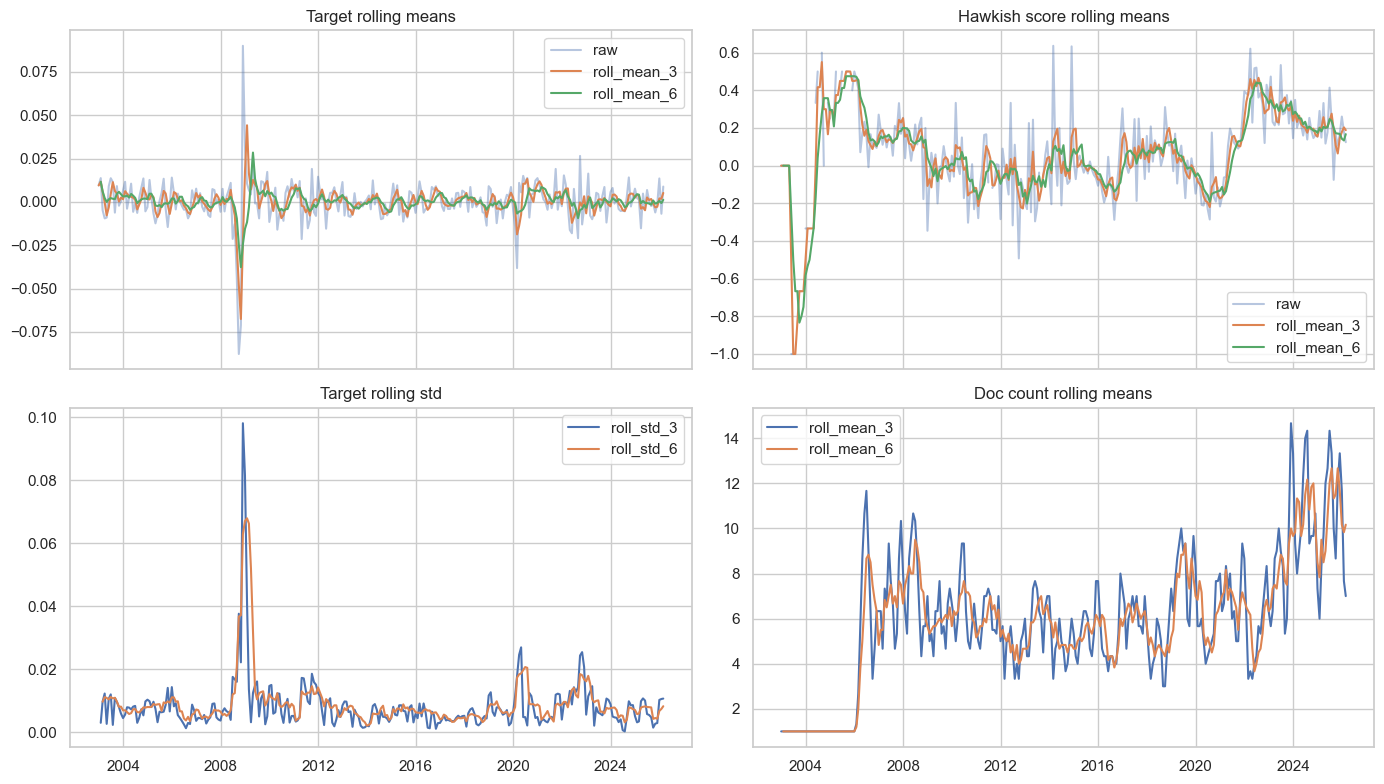

,feature,missing_share,zero_share,std,autocorr_lag1,shape_guess
0,hawkish_score,0.050179,0.082437,0.240073,0.568151,noisy / mixed
1,novelty,0.050179,0.050179,0.250648,0.580257,noisy / mixed
2,n_hawkish,0.050179,0.107527,29.356443,0.571853,noisy / mixed
3,n_dovish,0.050179,0.154122,15.334149,0.147428,noisy / mixed
4,n_neutral,0.050179,0.075269,37.767859,0.187428,noisy / mixed
5,n_target_sentences,0.050179,0.064516,70.580425,0.270943,noisy / mixed
6,doc_count,0.050179,0.050179,3.609046,0.398289,noisy / mixed


In [6]:
monthly_plot_df = monthly_eda.copy()
monthly_plot_df['month_start'] = monthly_plot_df['target_month'].dt.to_timestamp()

summary_cols = ['t5yie_diff1'] + MONTHLY_FEATURE_COLS
summary_stats = monthly_plot_df[summary_cols].describe().T
summary_stats['missing_rate'] = monthly_plot_df[summary_cols].isna().mean()
display(summary_stats)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
axes[0].plot(monthly_plot_df['month_start'], monthly_plot_df['t5yie_diff1'], color='black', label='t5yie_diff1')
axes[0].set_title('Target over time')
axes[0].legend()

axes[1].plot(monthly_plot_df['month_start'], monthly_plot_df['hawkish_score'], label='hawkish_score')
axes[1].plot(monthly_plot_df['month_start'], monthly_plot_df['novelty'], label='novelty')
axes[1].set_title('Main sentiment features over time')
axes[1].legend()

axes[2].plot(monthly_plot_df['month_start'], monthly_plot_df['doc_count'], label='doc_count')
axes[2].plot(monthly_plot_df['month_start'], monthly_plot_df['n_target_sentences'], label='n_target_sentences')
axes[2].set_title('Coverage metrics over time')
axes[2].legend()
plt.tight_layout(); plt.show()

for col in ['t5yie_diff1', 'hawkish_score', 'novelty', 'doc_count', 'n_target_sentences']:
    monthly_plot_df[f'{col}_roll_mean_3'] = monthly_plot_df[col].rolling(3, min_periods=1).mean()
    monthly_plot_df[f'{col}_roll_std_3'] = monthly_plot_df[col].rolling(3, min_periods=2).std()
    monthly_plot_df[f'{col}_roll_mean_6'] = monthly_plot_df[col].rolling(6, min_periods=2).mean()
    monthly_plot_df[f'{col}_roll_std_6'] = monthly_plot_df[col].rolling(6, min_periods=3).std()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes[0, 0].plot(monthly_plot_df['month_start'], monthly_plot_df['t5yie_diff1'], alpha=0.4, label='raw')
axes[0, 0].plot(monthly_plot_df['month_start'], monthly_plot_df['t5yie_diff1_roll_mean_3'], label='roll_mean_3')
axes[0, 0].plot(monthly_plot_df['month_start'], monthly_plot_df['t5yie_diff1_roll_mean_6'], label='roll_mean_6')
axes[0, 0].set_title('Target rolling means'); axes[0, 0].legend()

axes[0, 1].plot(monthly_plot_df['month_start'], monthly_plot_df['hawkish_score'], alpha=0.4, label='raw')
axes[0, 1].plot(monthly_plot_df['month_start'], monthly_plot_df['hawkish_score_roll_mean_3'], label='roll_mean_3')
axes[0, 1].plot(monthly_plot_df['month_start'], monthly_plot_df['hawkish_score_roll_mean_6'], label='roll_mean_6')
axes[0, 1].set_title('Hawkish score rolling means'); axes[0, 1].legend()

axes[1, 0].plot(monthly_plot_df['month_start'], monthly_plot_df['t5yie_diff1_roll_std_3'], label='roll_std_3')
axes[1, 0].plot(monthly_plot_df['month_start'], monthly_plot_df['t5yie_diff1_roll_std_6'], label='roll_std_6')
axes[1, 0].set_title('Target rolling std'); axes[1, 0].legend()

axes[1, 1].plot(monthly_plot_df['month_start'], monthly_plot_df['doc_count_roll_mean_3'], label='roll_mean_3')
axes[1, 1].plot(monthly_plot_df['month_start'], monthly_plot_df['doc_count_roll_mean_6'], label='roll_mean_6')
axes[1, 1].set_title('Doc count rolling means'); axes[1, 1].legend()
plt.tight_layout(); plt.show()


def profile(s: pd.Series) -> dict:
    return {
        'missing_share': float(s.isna().mean()),
        'zero_share': float((s.fillna(0) == 0).mean()),
        'std': float(s.std(skipna=True)),
        'autocorr_lag1': float(s.autocorr(1)) if s.notna().sum() > 2 else np.nan,
    }

rows = []
for c in MONTHLY_FEATURE_COLS:
    row = {'feature': c}
    row.update(profile(monthly_plot_df[c]))
    rows.append(row)
profile_df = pd.DataFrame(rows)
profile_df['shape_guess'] = np.select(
    [profile_df['missing_share'] > 0.40, profile_df['zero_share'] > 0.60, profile_df['autocorr_lag1'].abs() > 0.60],
    ['sparse', 'regime-like / sparse', 'trend-like / persistent'],
    default='noisy / mixed',
)
display(profile_df.sort_values('missing_share', ascending=False))


## 6) Target-Feature Relationship Diagnostics


,corr_with_t5yie_diff1
hawkish_score,-0.113032
novelty,-0.069985
doc_count,-0.064560
n_neutral,-0.056939
n_hawkish,-0.051545
n_target_sentences,-0.043560
n_dovish,0.038419


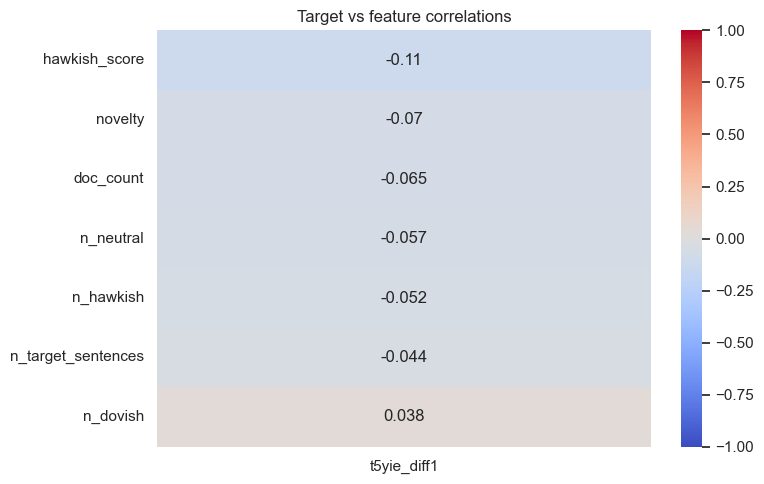

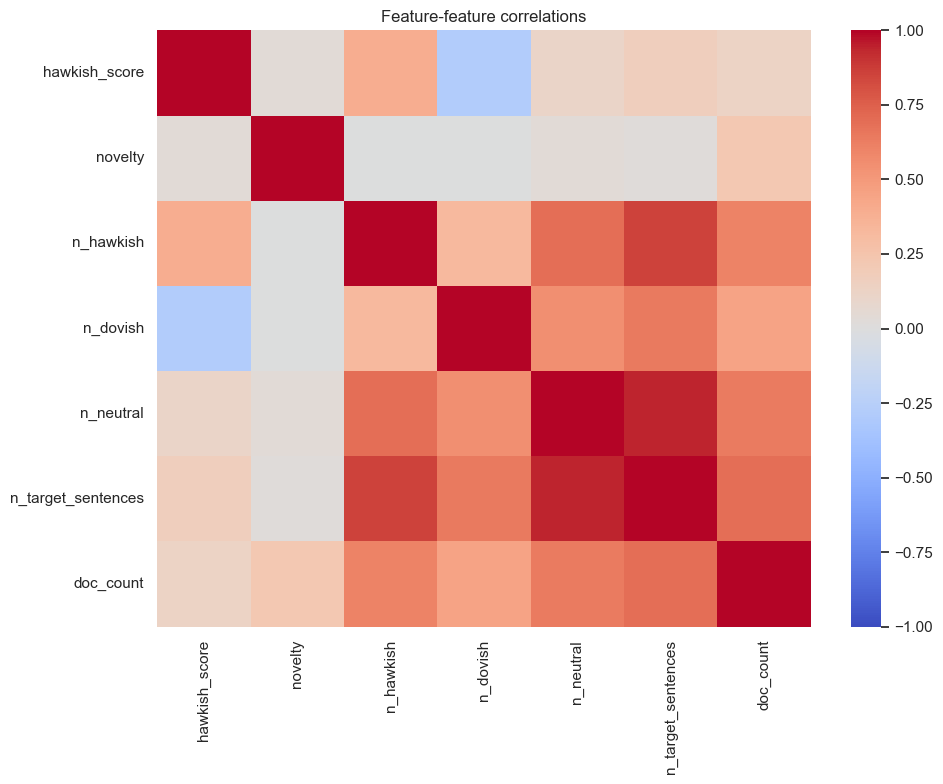

lag,0,1,2,3,4,5,6
feature,,,,,,,
doc_count,-0.064560,-0.057856,0.011234,-0.090226,-0.083144,-0.096524,-0.024667
hawkish_score,-0.113032,-0.135191,-0.076566,-0.068178,-0.072649,-0.035774,-0.053067
n_dovish,0.038419,0.001623,0.096240,0.024054,-0.029817,-0.001163,0.021921
n_hawkish,-0.051545,-0.123168,-0.043205,-0.108492,-0.125003,-0.095915,-0.065253
n_neutral,-0.056939,-0.141915,-0.037233,-0.170478,-0.115608,-0.021588,-0.062885
n_target_sentences,-0.043560,-0.126802,-0.016991,-0.131031,-0.120302,-0.051652,-0.056028
novelty,-0.069985,-0.014861,-0.020795,-0.088747,-0.016792,-0.057618,-0.079480


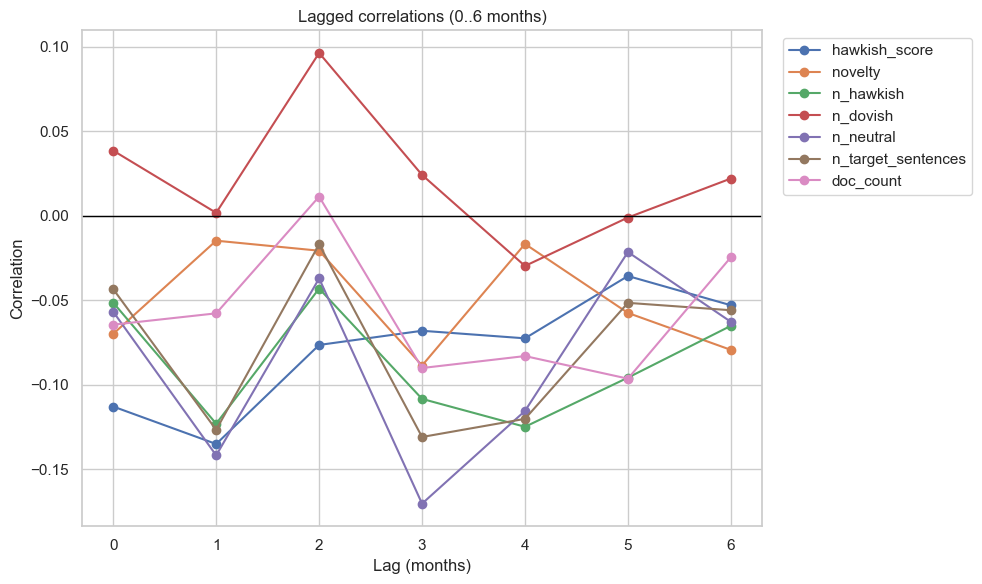

variant,first_diff,raw_level,rolling_mean_3
feature,,,
doc_count,-0.008533,-0.064560,-0.052019
hawkish_score,0.002264,-0.113032,-0.126555
n_dovish,0.030104,0.038419,0.053105
n_hawkish,0.079370,-0.051545,-0.086915
n_neutral,0.069608,-0.056939,-0.108956
n_target_sentences,0.072555,-0.043560,-0.083720
novelty,-0.070557,-0.069985,-0.046421


,feature,best_lag_0_to_6,best_corr,best_abs_corr,signal_label
4,n_neutral,3,-0.170478,0.170478,moderate_lagged_signal
0,hawkish_score,1,-0.135191,0.135191,weak_to_moderate_signal
5,n_target_sentences,3,-0.131031,0.131031,weak_to_moderate_signal
2,n_hawkish,4,-0.125003,0.125003,weak_to_moderate_signal
6,doc_count,5,-0.096524,0.096524,weak_to_moderate_signal
3,n_dovish,2,0.096240,0.096240,weak_to_moderate_signal
1,novelty,3,-0.088747,0.088747,weak_to_moderate_signal


In [7]:
corr_df = monthly_eda[['t5yie_diff1'] + MONTHLY_FEATURE_COLS].copy()

target_feature_corr = corr_df.corr(numeric_only=True)['t5yie_diff1'].drop('t5yie_diff1').sort_values(key=lambda s: s.abs(), ascending=False)
feature_feature_corr = corr_df[MONTHLY_FEATURE_COLS].corr(numeric_only=True)

display(target_feature_corr.to_frame('corr_with_t5yie_diff1'))

plt.figure(figsize=(8,5))
sns.heatmap(target_feature_corr.to_frame(), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Target vs feature correlations')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(feature_feature_corr, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Feature-feature correlations')
plt.tight_layout(); plt.show()


def lagged_corr_table(df: pd.DataFrame, target_col: str, feature_cols: list[str], max_lag: int = 6) -> pd.DataFrame:
    rows = []
    for feat in feature_cols:
        for lag in range(max_lag + 1):
            shifted = df[feat].shift(lag)
            valid = df[target_col].notna() & shifted.notna()
            corr = df.loc[valid, target_col].corr(shifted.loc[valid]) if valid.sum() >= 12 else np.nan
            rows.append({'feature': feat, 'lag': lag, 'corr': corr, 'n_obs': int(valid.sum())})
    return pd.DataFrame(rows)

lag_corr_df = lagged_corr_table(monthly_eda, 't5yie_diff1', MONTHLY_FEATURE_COLS, max_lag=6)
display(lag_corr_df.pivot(index='feature', columns='lag', values='corr'))

plt.figure(figsize=(10,6))
for feat in MONTHLY_FEATURE_COLS:
    sub = lag_corr_df[lag_corr_df['feature'] == feat]
    plt.plot(sub['lag'], sub['corr'], marker='o', label=feat)
plt.axhline(0.0, color='black', linewidth=1)
plt.title('Lagged correlations (0..6 months)')
plt.xlabel('Lag (months)'); plt.ylabel('Correlation')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.show()

comp_rows = []
for feat in MONTHLY_FEATURE_COLS:
    variants = {
        'raw_level': monthly_eda[feat],
        'first_diff': monthly_eda[feat].diff(),
        'rolling_mean_3': monthly_eda[feat].rolling(3, min_periods=2).mean(),
    }
    for vname, s in variants.items():
        valid = monthly_eda['t5yie_diff1'].notna() & s.notna()
        corr = monthly_eda.loc[valid, 't5yie_diff1'].corr(s.loc[valid]) if valid.sum() >= 12 else np.nan
        comp_rows.append({'feature': feat, 'variant': vname, 'corr_with_target': corr, 'n_obs': int(valid.sum())})

transform_compare_df = pd.DataFrame(comp_rows)
display(transform_compare_df.pivot(index='feature', columns='variant', values='corr_with_target'))

sig_rows = []
for feat in MONTHLY_FEATURE_COLS:
    sub = lag_corr_df[lag_corr_df['feature'] == feat]
    if sub['corr'].notna().any():
        idx = sub['corr'].abs().idxmax()
        best_lag = int(sub.loc[idx, 'lag'])
        best_corr = float(sub.loc[idx, 'corr'])
    else:
        best_lag = np.nan
        best_corr = np.nan
    sig_rows.append({'feature': feat, 'best_lag_0_to_6': best_lag, 'best_corr': best_corr, 'best_abs_corr': abs(best_corr) if pd.notna(best_corr) else np.nan})

signal_summary = pd.DataFrame(sig_rows).sort_values('best_abs_corr', ascending=False)
signal_summary['signal_label'] = np.select(
    [signal_summary['best_abs_corr'] >= 0.15, signal_summary['best_abs_corr'] >= 0.08, signal_summary['best_abs_corr'] >= 0.04],
    ['moderate_lagged_signal', 'weak_to_moderate_signal', 'weak_signal'],
    default='very_weak_or_noisy',
)
display(signal_summary)


## 7) Secondary Daily Event-Window Checks


daily regime thresholds: {'q20': -0.06382978723404255, 'q80': 0.5}


,n_obs,mean_target,median_target,mean_abs_target
hawkish_7d_regime,,,,
high,1230,-0.001512,0.0,0.029626
low,1164,-0.000447,0.0,0.031873
mid,3414,0.001063,0.0,0.029265


,n_obs,mean_target,median_target,mean_abs_target
has_event_shift1,,,,
0,4606,-0.000041,0.0,0.029798
1,1202,0.001198,0.0,0.030116


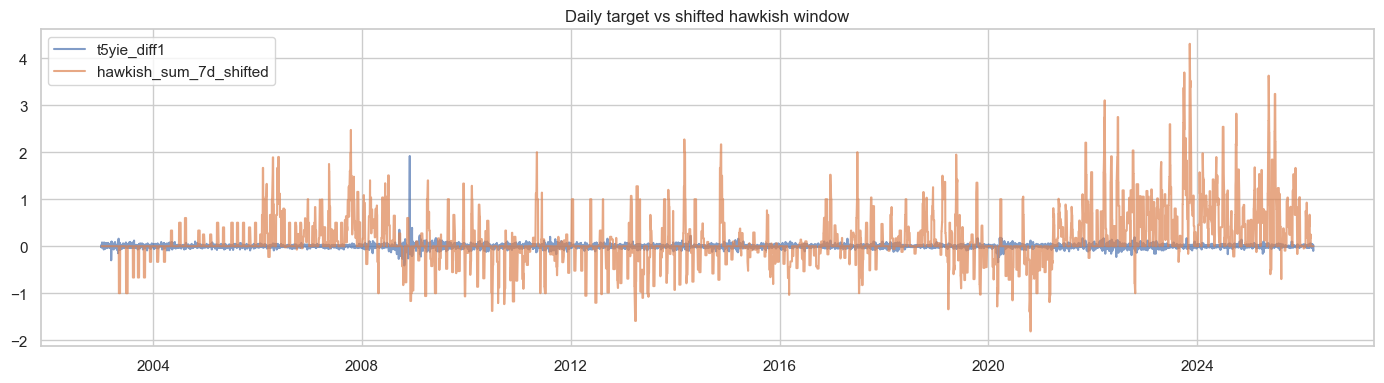

In [8]:
feats_daily = (
    features_df.groupby('date', as_index=False)
    .agg(
        hawkish_daily_sum=('hawkish_score', 'sum'),
        hawkish_daily_mean=('hawkish_score', 'mean'),
        doc_count=('doc_id', 'count'),
        n_target_sentences_daily=('n_target_sentences', 'sum'),
    )
    .sort_values('date')
)

daily_eda = target_df[['date', 't5yie_diff1']].merge(feats_daily, on='date', how='left').sort_values('date').reset_index(drop=True)
daily_eda['has_event'] = (daily_eda['doc_count'].fillna(0) > 0).astype(int)
daily_eda['hawkish_daily_sum_filled'] = daily_eda['hawkish_daily_sum'].fillna(0.0)
daily_eda['hawkish_daily_sum_shift1'] = daily_eda['hawkish_daily_sum_filled'].shift(1)
daily_eda['has_event_shift1'] = daily_eda['has_event'].shift(1).fillna(0).astype(int)
daily_eda['doc_count_shift1'] = daily_eda['doc_count'].fillna(0).shift(1)

# Assertion 3
assert daily_eda['hawkish_daily_sum_shift1'].equals(daily_eda['hawkish_daily_sum_filled'].shift(1))
assert daily_eda['has_event_shift1'].equals(daily_eda['has_event'].shift(1).fillna(0).astype(int))

daily_eda['hawkish_sum_7d_shifted'] = daily_eda['hawkish_daily_sum_shift1'].rolling(7, min_periods=1).sum()
daily_eda['hawkish_sum_14d_shifted'] = daily_eda['hawkish_daily_sum_shift1'].rolling(14, min_periods=1).sum()

q20, q80 = daily_eda['hawkish_sum_7d_shifted'].dropna().quantile([0.2, 0.8])
daily_eda['hawkish_7d_regime'] = np.select(
    [daily_eda['hawkish_sum_7d_shifted'] <= q20, daily_eda['hawkish_sum_7d_shifted'] >= q80],
    ['low', 'high'],
    default='mid',
)

daily_regime_stats = daily_eda.groupby('hawkish_7d_regime').agg(
    n_obs=('t5yie_diff1', 'size'),
    mean_target=('t5yie_diff1', 'mean'),
    median_target=('t5yie_diff1', 'median'),
    mean_abs_target=('t5yie_diff1', lambda s: s.abs().mean()),
)
event_shift_stats = daily_eda.groupby('has_event_shift1').agg(
    n_obs=('t5yie_diff1', 'size'),
    mean_target=('t5yie_diff1', 'mean'),
    median_target=('t5yie_diff1', 'median'),
    mean_abs_target=('t5yie_diff1', lambda s: s.abs().mean()),
)

print('daily regime thresholds:', {'q20': float(q20), 'q80': float(q80)})
display(daily_regime_stats)
display(event_shift_stats)

plt.figure(figsize=(14,4))
plt.plot(daily_eda['date'], daily_eda['t5yie_diff1'], label='t5yie_diff1', alpha=0.7)
plt.plot(daily_eda['date'], daily_eda['hawkish_sum_7d_shifted'], label='hawkish_sum_7d_shifted', alpha=0.7)
plt.title('Daily target vs shifted hawkish window')
plt.legend(); plt.tight_layout(); plt.show()


## 8) Regime/Event Analysis


In [9]:
monthly_regime_df = monthly_eda[['target_month', 't5yie_diff1', 'hawkish_score', 'doc_count', 'n_target_sentences']].dropna(subset=['t5yie_diff1', 'hawkish_score']).reset_index(drop=True)

hq20, hq80 = monthly_regime_df['hawkish_score'].quantile([0.2, 0.8])
monthly_regime_df['hawkish_regime'] = np.select(
    [monthly_regime_df['hawkish_score'] <= hq20, monthly_regime_df['hawkish_score'] >= hq80],
    ['low_hawkish', 'high_hawkish'],
    default='mid_hawkish',
)

monthly_regime_stats = monthly_regime_df.groupby('hawkish_regime').agg(
    n_obs=('t5yie_diff1', 'size'),
    mean_target=('t5yie_diff1', 'mean'),
    median_target=('t5yie_diff1', 'median'),
    mean_abs_target=('t5yie_diff1', lambda s: s.abs().mean()),
)
display(monthly_regime_stats)

mid_abs = monthly_regime_stats.loc['mid_hawkish', 'mean_abs_target'] if 'mid_hawkish' in monthly_regime_stats.index else np.nan
extreme_abs = monthly_regime_stats.loc[[i for i in ['low_hawkish', 'high_hawkish'] if i in monthly_regime_stats.index], 'mean_abs_target'].mean()
print('extreme_vs_mid_abs_ratio:', (extreme_abs / mid_abs) if pd.notna(mid_abs) and mid_abs != 0 else np.nan)

# Document-date concentration check

doc_dates = (
    features_df.loc[features_df['source_type'].astype(str).str.lower() == 'document', 'date']
    .dropna().drop_duplicates().sort_values()
)

target_daily_sorted = target_df[['date', 't5yie_diff1']].sort_values('date').reset_index(drop=True)
if len(doc_dates) > 0:
    doc_df = pd.DataFrame({'doc_date': doc_dates}).sort_values('doc_date')
    prev_match = pd.merge_asof(target_daily_sorted, doc_df, left_on='date', right_on='doc_date', direction='backward')
    next_match = pd.merge_asof(target_daily_sorted, doc_df, left_on='date', right_on='doc_date', direction='forward')
    days_prev = (target_daily_sorted['date'] - prev_match['doc_date']).dt.days.abs()
    days_next = (next_match['doc_date'] - target_daily_sorted['date']).dt.days.abs()

    doc_window_df = target_daily_sorted.copy()
    doc_window_df['days_to_prev_doc'] = days_prev
    doc_window_df['days_to_next_doc'] = days_next
    doc_window_df['days_to_nearest_doc'] = doc_window_df[['days_to_prev_doc', 'days_to_next_doc']].min(axis=1)
    doc_window_df['within_doc_window_3d'] = doc_window_df['days_to_nearest_doc'] <= 3

    doc_window_stats = doc_window_df.groupby('within_doc_window_3d').agg(
        n_obs=('t5yie_diff1', 'size'),
        mean_target=('t5yie_diff1', 'mean'),
        median_target=('t5yie_diff1', 'median'),
        mean_abs_target=('t5yie_diff1', lambda s: s.abs().mean()),
    )
    display(doc_window_stats)
else:
    print('No document dates found for window check.')


,n_obs,mean_target,median_target,mean_abs_target
hawkish_regime,,,,
high_hawkish,53,-0.001086,-0.000952,0.008093
low_hawkish,53,0.002592,0.005000,0.009044
mid_hawkish,159,0.000059,0.000455,0.007191


extreme_vs_mid_abs_ratio: 1.191546971993161


,n_obs,mean_target,median_target,mean_abs_target
within_doc_window_3d,,,,
False,4848,0.000410,0.0,0.029144
True,960,-0.000771,0.0,0.033500


## 9) Decision Section (Explicit Answers)


In [10]:
upper = feature_feature_corr.where(np.triu(np.ones(feature_feature_corr.shape), k=1).astype(bool))
redundant_pairs = upper.stack().reset_index().rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'corr'})
redundant_pairs['abs_corr'] = redundant_pairs['corr'].abs()
high_redundant_pairs = redundant_pairs[redundant_pairs['abs_corr'] >= 0.85].sort_values('abs_corr', ascending=False)

candidate_useful = signal_summary[signal_summary['best_abs_corr'] >= 0.05].copy()
candidate_noisy = signal_summary[signal_summary['best_abs_corr'] < 0.04].copy()
useful_features = candidate_useful['feature'].tolist() or signal_summary.head(3)['feature'].tolist()
noisy_features = candidate_noisy['feature'].tolist()

has_any_signal = signal_summary['best_abs_corr'].fillna(0).max() >= 0.05
exogenous_decision = 'Yes, run exogenous models' if has_any_signal else 'Weak signal; low-priority exogenous trial'
usage_decision = 'both' if has_any_signal else 'dashboard / interpretability-only (+ one lightweight model trial)'

print('Decision Answers')
print('=' * 80)
print('1) Potentially useful features:')
print('   ', useful_features)
print('2) Mostly noisy/redundant features:')
print('   noisy:', noisy_features if noisy_features else 'None clearly dominated as noise under thresholds')
if high_redundant_pairs.empty:
    print('   redundant pairs: none with |corr| >= 0.85')
else:
    display(high_redundant_pairs.head(20))
print('3) Should exogenous features be modeled?')
print('   ', exogenous_decision)
print('4) Use as direct inputs / dashboard / both?')
print('   ', usage_decision)
print('5) Top 3 next experiments:')
print('   1. Monthly ARX/SARIMAX on t5yie_diff1 with lagged exogenous features (0..6 lag sweep).')
print('   2. Daily model with leakage-safe shifted event-window features (7d/14d hawkish windows).')
print('   3. Source-type split (document vs speech) exogenous comparison.')

decision_artifact = {
    'useful_features': useful_features,
    'noisy_features': noisy_features,
    'exogenous_decision': exogenous_decision,
    'usage_decision': usage_decision,
}


Decision Answers
1) Potentially useful features:
    ['n_neutral', 'hawkish_score', 'n_target_sentences', 'n_hawkish', 'doc_count', 'n_dovish', 'novelty']
2) Mostly noisy/redundant features:
   noisy: None clearly dominated as noise under thresholds


,feature_a,feature_b,corr,abs_corr
18,n_neutral,n_target_sentences,0.940925,0.940925
13,n_hawkish,n_target_sentences,0.855790,0.855790


3) Should exogenous features be modeled?
    Yes, run exogenous models
4) Use as direct inputs / dashboard / both?
    both
5) Top 3 next experiments:
   1. Monthly ARX/SARIMAX on t5yie_diff1 with lagged exogenous features (0..6 lag sweep).
   2. Daily model with leakage-safe shifted event-window features (7d/14d hawkish windows).
   3. Source-type split (document vs speech) exogenous comparison.


In [11]:
print('Short Plain-English Summary')
print('=' * 80)
print('This EDA evaluates lagged text-feature signal for t5yie_diff1 under strict no-lookahead alignment.')
print(f"Potentially useful features: {decision_artifact['useful_features']}")
print(f"Noisy features: {decision_artifact['noisy_features']}")
print(f"Modeling recommendation: {decision_artifact['exogenous_decision']}")
print(f"Usage recommendation: {decision_artifact['usage_decision']}")
print('Next experiments: monthly lagged exogenous model, daily event-window model, and source-type split model.')


Short Plain-English Summary
This EDA evaluates lagged text-feature signal for t5yie_diff1 under strict no-lookahead alignment.
Potentially useful features: ['n_neutral', 'hawkish_score', 'n_target_sentences', 'n_hawkish', 'doc_count', 'n_dovish', 'novelty']
Noisy features: []
Modeling recommendation: Yes, run exogenous models
Usage recommendation: both
Next experiments: monthly lagged exogenous model, daily event-window model, and source-type split model.


## Reproducibility Checks


In [12]:
# Assertion 1 (repeat)
assert target_df['date'].is_monotonic_increasing
assert target_df['date'].is_unique

# Deterministic ordering checks
assert features_df['date'].is_monotonic_increasing
assert monthly_eda['target_month'].is_monotonic_increasing
assert daily_eda['date'].is_monotonic_increasing

# Stable row counts
assert len(monthly_eda) == len(target_monthly)
assert len(daily_eda) == len(target_df)

print('All core assertions and reproducibility checks passed.')


All core assertions and reproducibility checks passed.
